In [1]:
%cd ../..

/home/bhkuser/bhklab/katy/readii_2_roqc


In [2]:
from damply import dirs
import SimpleITK as sitk
from readii.image_processing import displayCTSegOverlay, displayImageSlice
import numpy as np
import matplotlib.pyplot as plt

from readii.negative_controls_refactor.manager import NegativeControlManager
from readii.process.images.crop import crop_and_resize_image_and_mask
from imgtools.coretypes.box import RegionBox
import matplotlib.patches as patches
import matplotlib.colors as mcolors
import matplotlib as mpl

## NSCLC-Radiomics example

In [3]:
image_path = dirs.PROCDATA / "TCIA_NSCLC-Radiomics/images/mit_NSCLC-Radiomics/LUNG1-136_0135/CT_40276376/CT.nii.gz"
mask_path = dirs.PROCDATA / "TCIA_NSCLC-Radiomics/images/mit_NSCLC-Radiomics/LUNG1-136_0135/RTSTRUCT_28082283/GTV.nii.gz"

2026-07-14 | WARNING | Environment variable 'PROCDATA' is not set. Using default path relative to project root.


In [4]:
image = sitk.ReadImage(image_path)
mask = sitk.ReadImage(mask_path)

In [5]:
disp_windows = {'Lung': [-1400, 150],
                'Abdomen': [-350, 450],
                'HeadNeck': [-360, 440]}

In [6]:
slice_idx = 65
anatomy = 'Lung'

dispMin = disp_windows[anatomy][0]
dispMax = disp_windows[anatomy][1]

<Axes: >

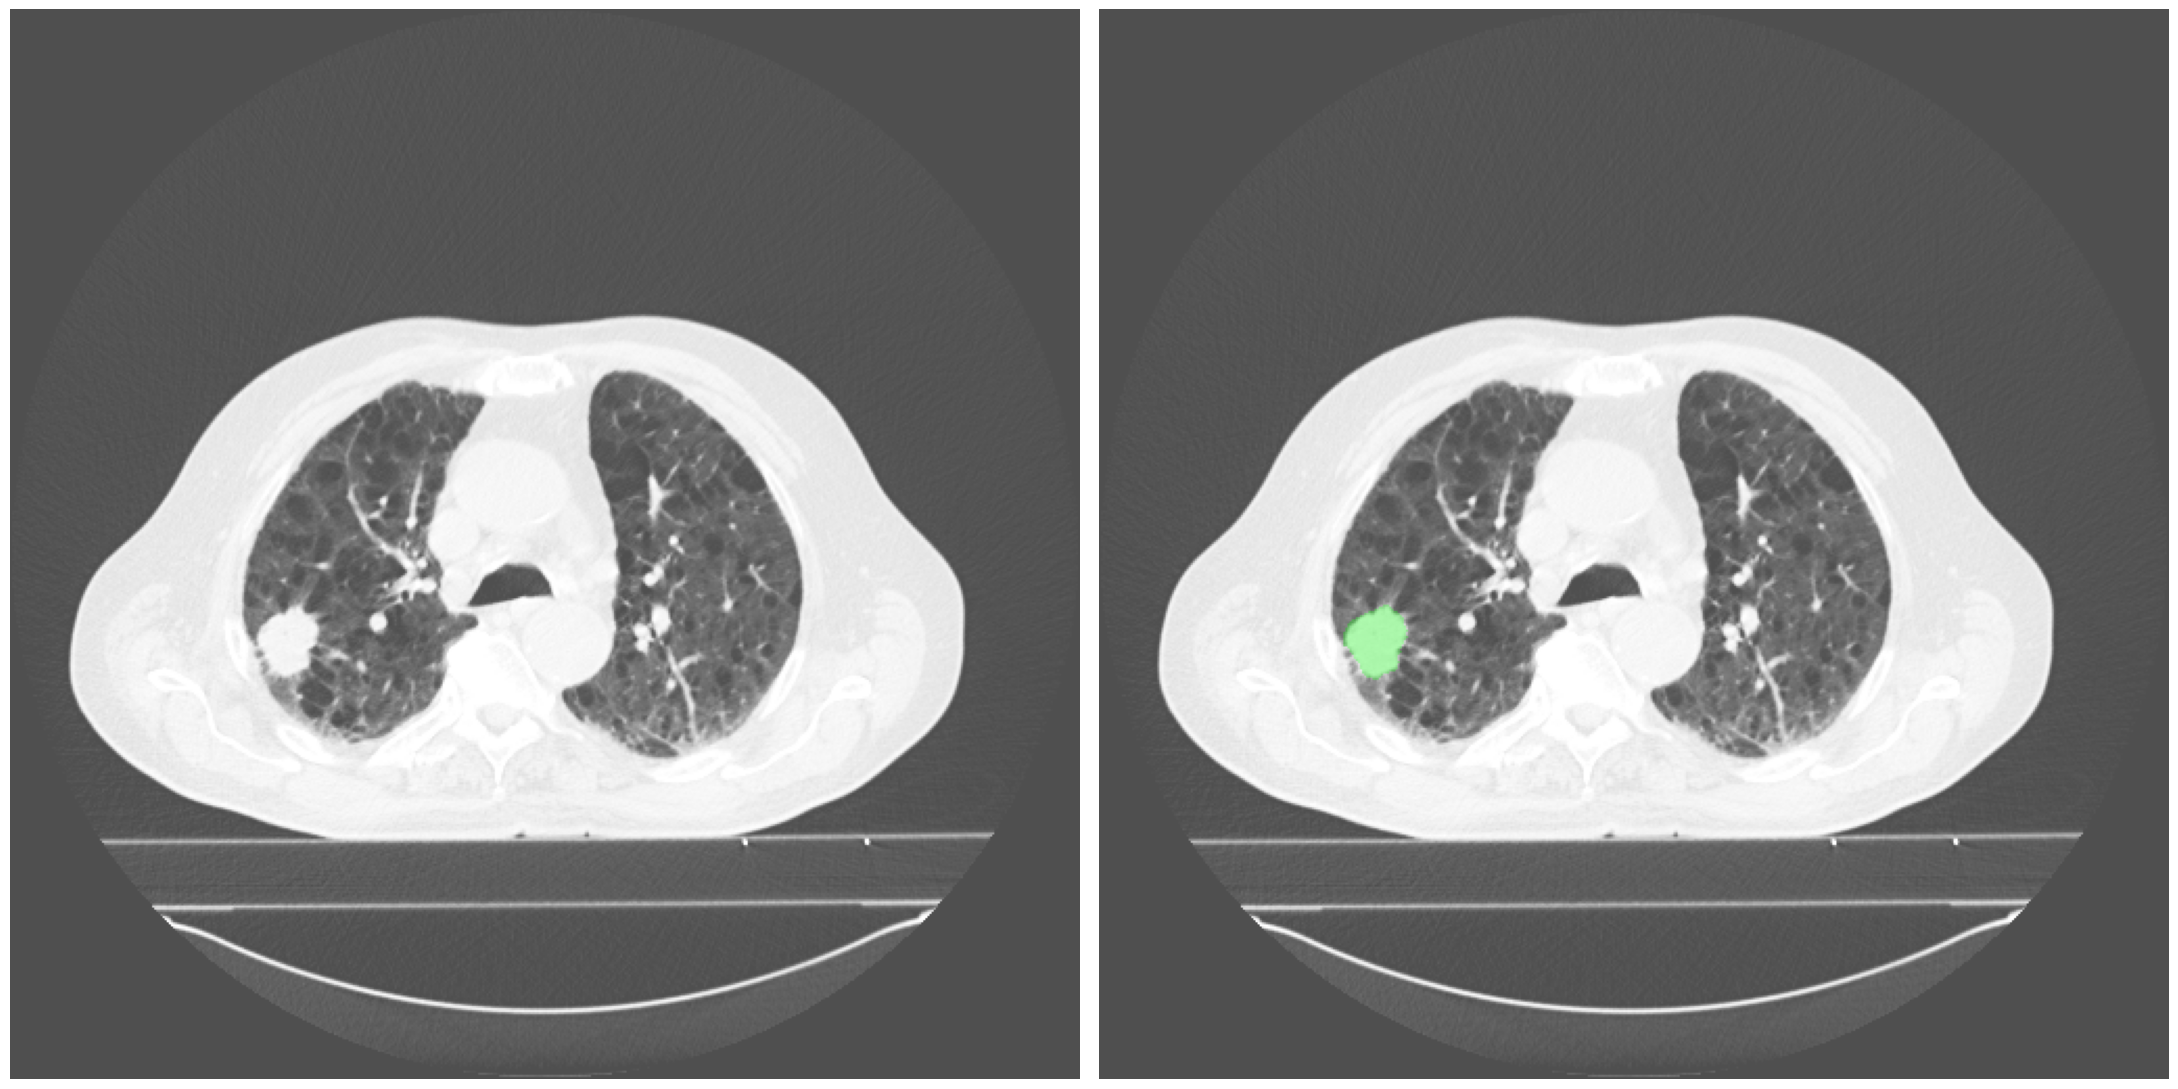

In [7]:
full_fig, full_ax = plt.subplots(1,2, figsize=(22,11), layout='tight')

displayImageSlice(image, slice_idx, dispMin=dispMin, dispMax=dispMax, ax=full_ax[0])
displayCTSegOverlay(image, mask, slice_idx, dispMin=dispMin, dispMax=dispMax, ax=full_ax[1])

# Cropped Images

In [6]:
def get_crop_box(crop_method, mask, resize_dimension, label=1):
    match crop_method:
        case "bounding_box":
            # Generate a bounding box around a mask
            crop_box = RegionBox.from_mask_bbox(mask, label)
        
        case "centroid":
            if resize_dimension is None:
                # Set to 50 if not provided -> default expected dimension for FMCIB
                centroid_dimension = 50
            elif isinstance(resize_dimension, (list, tuple, np.ndarray)):
                # Ensure all values are identical to form a cube; collapse to a single int
                unique_vals = {int(v) for v in resize_dimension}
                if len(unique_vals) == 1:
                    centroid_dimension = int(next(iter(unique_vals)))
                else:
                    message = (
                        "If using centroid crop method, resize_dimension must be a single value, "
                        "or a list/tuple/array of identical values, or None. "
                        f"Current value: {resize_dimension}."
                    )
                    raise ValueError(message)
            else:
                # Single scalar provided
                centroid_dimension = int(resize_dimension)
            # Generate a cube bounding box with resize dimension around the centroid of a mask
            crop_box = RegionBox.from_mask_centroid(mask, label, centroid_dimension)
        
        case "cube":
            # Generate a bounding box around the mask, then expand the dimensions to a cube with the maximum bounding box dimension
            crop_box = RegionBox.from_mask_bbox(mask, label)
            crop_box = crop_box.expand_to_cube(max(crop_box.size))
    
    return crop_box

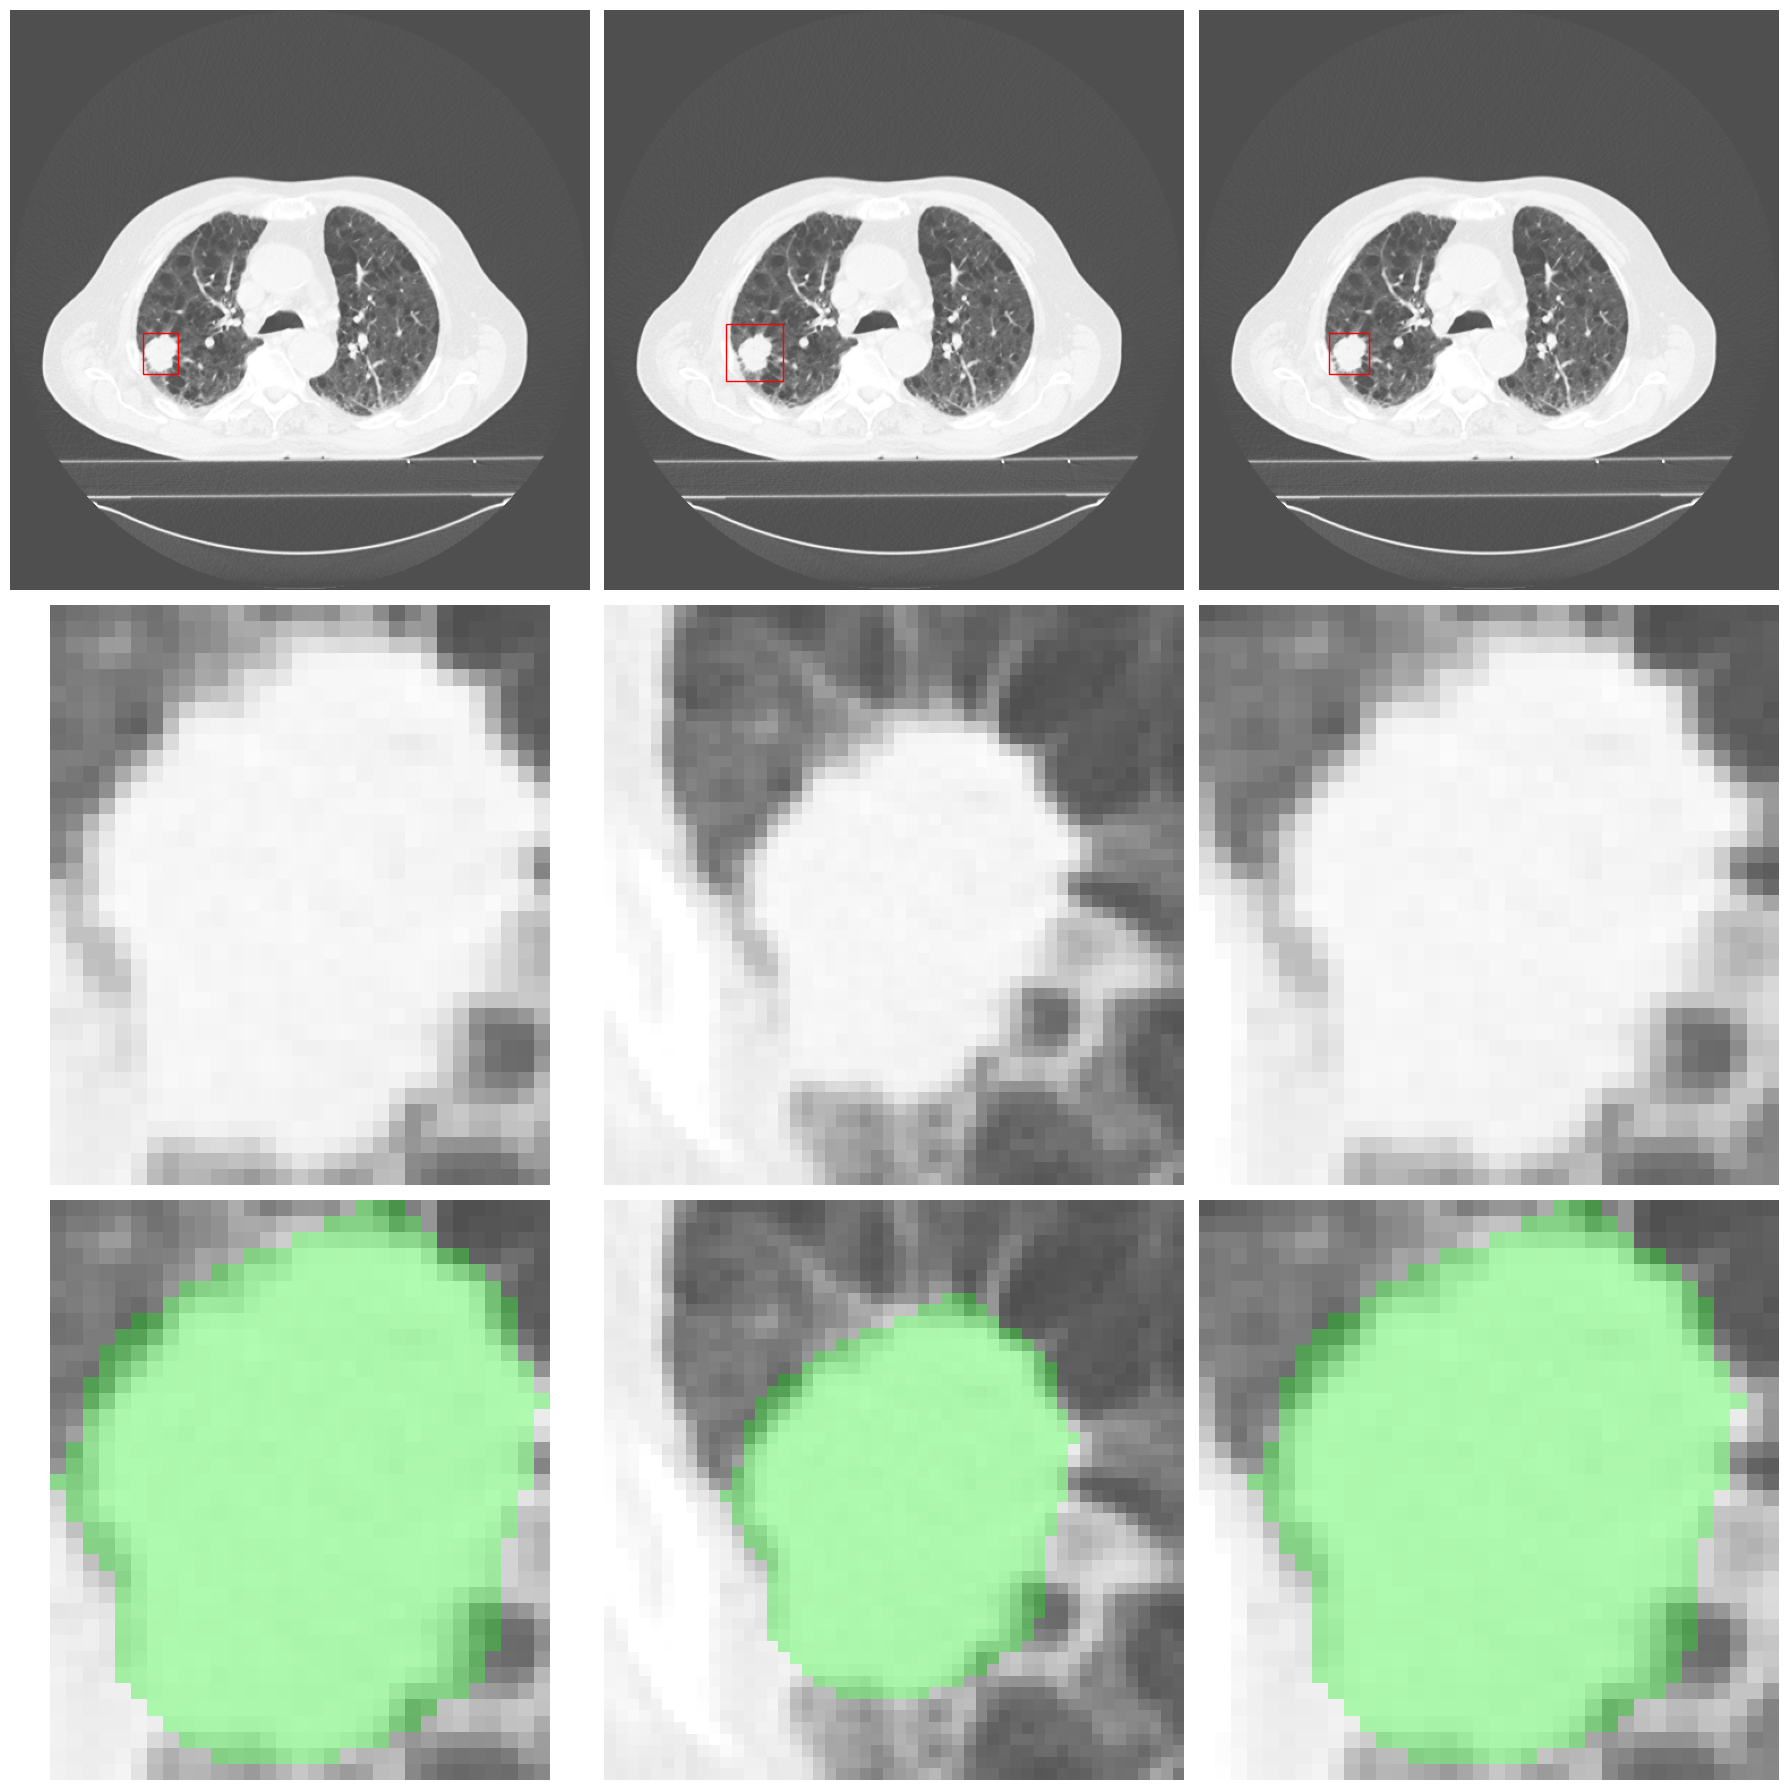

In [9]:
# resize = [50,50,50]
resize = None

crop_fig, crop_ax = plt.subplots(3,3, figsize=(18,18), layout='tight')

for idx, crop in enumerate(['bounding_box', 'centroid', 'cube']):
    crop_image, crop_mask = crop_and_resize_image_and_mask(image, 
                                                            mask, 
                                                            crop_method = crop, 
                                                            resize_dimension = resize)
    
    crop_slice_idx = crop_mask.GetSize()[2] // 2

    crop_box = get_crop_box(crop, mask, resize)
    full_with_box_ax = crop_ax[0][idx]
    displayImageSlice(image, slice_idx, dispMin=dispMin, dispMax=dispMax, ax=full_with_box_ax)
    rect = patches.Rectangle((crop_box.min.x, crop_box.min.y), crop_box.size.width, crop_box.size.height,
                        linewidth=1, edgecolor='r', facecolor='none')
    full_with_box_ax.add_patch(rect)

    displayImageSlice(crop_image, crop_slice_idx, dispMin=dispMin, dispMax=dispMax, ax=crop_ax[1][idx])
    displayCTSegOverlay(crop_image, crop_mask, crop_slice_idx, dispMin=dispMin, dispMax=dispMax, ax=crop_ax[2][idx])
    


In [12]:
crop_box = RegionBox.from_mask_bbox(mask)
crop_box

RegionBox(
	min=Coordinate3D(x=117, y=285, z=61),
	max=Coordinate3D(x=148, y=321, z=72)
	size=Size3D(w=31, h=36, d=11)
)

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(10,10))


crop_box = get_crop_box('cube', mask, None)
displayImageSlice(image, slice_idx, dispMin=dispMin, dispMax=dispMax, ax=ax)

rect = patches.Rectangle((crop_box.min.x, crop_box.min.y), crop_box.size.width, crop_box.size.height,
                        linewidth=1, edgecolor='r', facecolor='none')

ax.add_patch(rect)


<Axes: >

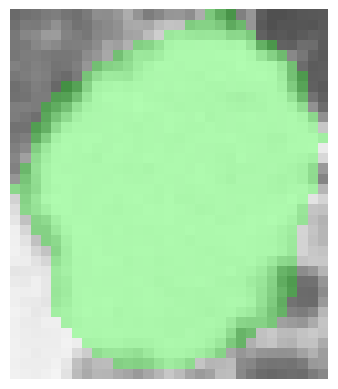

In [13]:
# PyRadiomics crop
from radiomics.imageoperations import checkMask, cropToTumorMask

bounding_box, corrected_mask = checkMask(image, mask, label=1)
input_image, input_mask = cropToTumorMask(image, mask, bounding_box, padDistance=0)

displayCTSegOverlay(input_image, input_mask, 5, dispMin=dispMin, dispMax=dispMax)

# Negative control images

In [ ]:
nc_dir_path = dirs.PROCDATA / "TCIA_NSCLC-Radiomics/images/readii_NSCLC-Radiomics/LUNG1-136_0135/CT_40276376/RTSTRUCT_28082283_GTV"

nc_full_fig, nc_full_ax = plt.subplots(3,3, figsize=(20,18), layout='tight')
nc_ax_flat = nc_full_ax.ravel()

for idx, file in enumerate(sorted(list(nc_dir_path.glob("*.nii.gz")))):
    nc_image = sitk.ReadImage(file)

    displayImageSlice(nc_image, slice_idx, dispMin=dispMin, dispMax=dispMax, ax=nc_ax_flat[idx])

In [ ]:
nc_dir_path = dirs.PROCDATA / "TCIA_NSCLC-Radiomics/images/readii_NSCLC-Radiomics/LUNG1-136_0135/CT_40276376/RTSTRUCT_28082283_GTV"

nc_full_fig, nc_full_ax = plt.subplots(3,3, figsize=(20,18), layout='tight')
nc_ax_flat = nc_full_ax.ravel()

for idx, file in enumerate(sorted(list(nc_dir_path.glob("*.nii.gz")))):
    nc_image = sitk.ReadImage(file)

    displayCTSegOverlay(nc_image, mask, slice_idx, dispMin=dispMin, dispMax=dispMax, ax=nc_ax_flat[idx])

<Axes: >

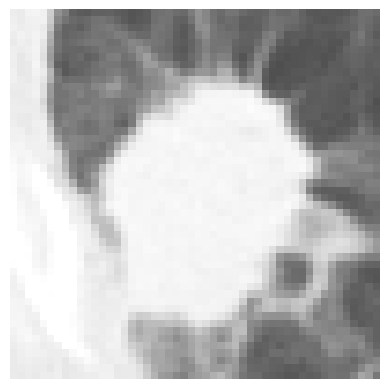

In [10]:
crop_image, crop_mask = crop_and_resize_image_and_mask(image, mask, crop_method='centroid', resize_dimension=50)
crop_slice_idx = crop_mask.GetSize()[2] // 2

displayCTSegOverlay(crop_image, crop_mask, crop_slice_idx, dispMin=dispMin, dispMax=dispMax, alpha=0)

CT_randomized_full.nii
CT_randomized_non_roi.nii
CT_randomized_roi.nii
CT_sampled_full.nii
CT_sampled_non_roi.nii
CT_sampled_roi.nii
CT_shuffled_full.nii
CT_shuffled_non_roi.nii
CT_shuffled_roi.nii


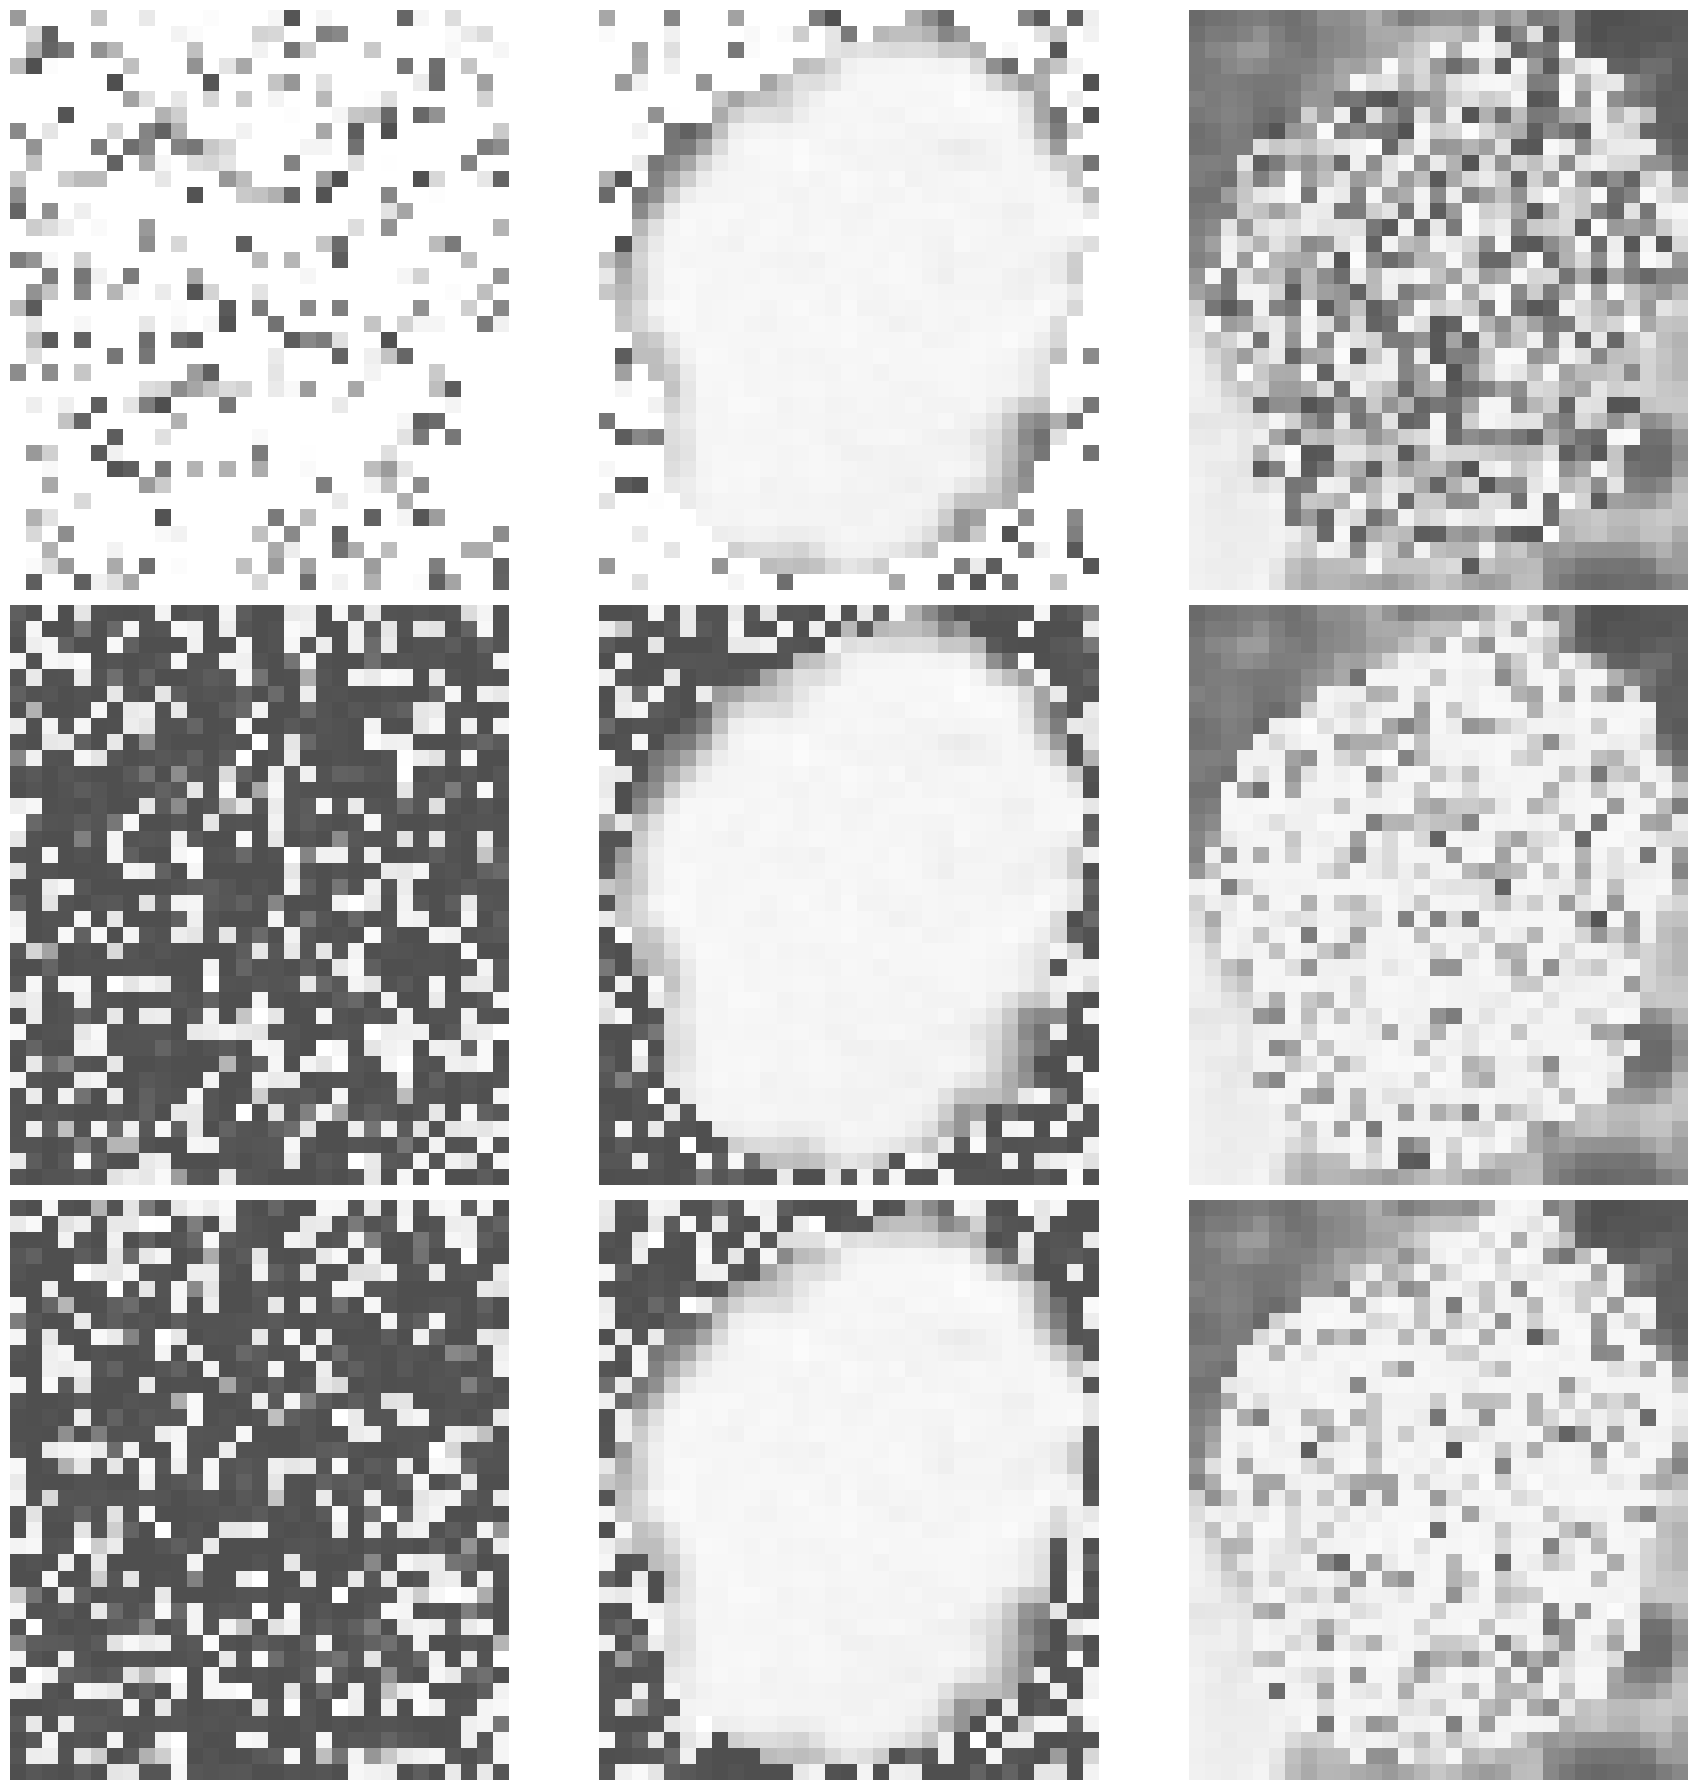

In [15]:
nc_dir_path = dirs.PROCDATA / "TCIA_NSCLC-Radiomics/images/readii_NSCLC-Radiomics/LUNG1-136_0135/CT_40276376/RTSTRUCT_28082283_GTV"

nc_full_fig, nc_full_ax = plt.subplots(3,3, figsize=(20,18), layout='tight')
nc_ax_flat = nc_full_ax.ravel()

for idx, file in enumerate(sorted(list(nc_dir_path.glob("*.nii.gz")))):
    print(file.stem)
    nc_image = sitk.ReadImage(file)

    crop_image, crop_mask = crop_and_resize_image_and_mask(nc_image, 
                                                            mask, 
                                                            crop_method = "bounding_box", 
                                                            resize_dimension = None)
    crop_slice_idx = crop_mask.GetSize()[2] // 2

    displayCTSegOverlay(crop_image, crop_mask, crop_slice_idx, dispMin=dispMin, dispMax=dispMax, ax=nc_ax_flat[idx], alpha=0)



# Donut Images

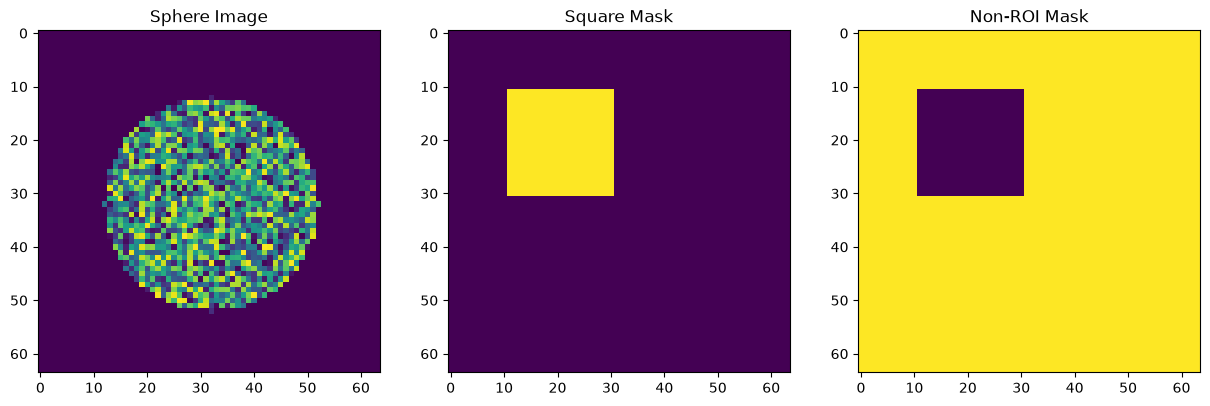

In [3]:
def create_donut_image(size: int = 64, radius: int = 20, max_thickness: int = 10) -> sitk.Image:
  """Generate a 3D donut-shaped SimpleITK image with varying thickness across slices."""
  grid = np.zeros((size, size, size), dtype=np.uint8)
  center = size // 2
  mid_slice = size // 2

  for z in range(size):
    # Calculate thickness for current slice based on distance from the middle slice
    thickness = max_thickness * (1 - abs(z - mid_slice) / mid_slice)  # Linear scaling
    for x in range(size):
      for y in range(size):
        distance_from_center = np.sqrt((x - center) ** 2 + (y - center) ** 2)
        if radius - thickness <= distance_from_center <= radius + thickness:
          grid[z, x, y] = 255  # Donut drawn along Z-axis (top-down view)

  return sitk.GetImageFromArray(grid)


def create_sphere_image(size: int = 64, radius: int = 20, seed=10) -> sitk.Image:
  """Generate a 3D sphere-shaped SimpleITK image."""
  randNumGen = np.random.default_rng(seed=seed)

  grid = np.zeros((size, size, size), dtype=np.uint8)
  center = size // 2

  for z in range(size):
    for x in range(size):
      for y in range(size):
        distance_from_center = np.sqrt((x - center) ** 2 + (y - center) ** 2 + (z - center) ** 2)
        if distance_from_center <= radius:
          grid[z, x, y] = randNumGen.integers(1, 255, endpoint=True, size=1)[0]  # Fill the sphere with random values to create texture

  return sitk.GetImageFromArray(grid)


def create_square_mask(image: sitk.Image, side_length: int = 20, mask_start_slice: int = -1, mask_end_slice: int = -1) -> sitk.Image:
  """
  Create a square mask for a given SimpleITK image.

  The square is placed in the top-left quadrant of the image, covering part of the donut.

  Parameters
  ----------
  image : sitk.Image
      The input image for which the mask is created.
  side_length : int, default 20
      The length of one side of the square mask in pixels.

  Returns
  -------
  sitk.Image
      A binary mask image with the square region set to 1.
  """
  # Get the dimensions of the input image
  size = sitk.GetArrayFromImage(image).shape  # (z, y, x)

  # Define the position of the square in the top-left quadrant
  # Offset from the center to ensure it covers part of the donut
  start_x = size[2] // 3 - side_length // 2
  start_y = size[1] // 3 - side_length // 2

  # Ensure the square is within bounds
  start_x = max(0, start_x)
  start_y = max(0, start_y)
  end_x = min(size[2], start_x + side_length)
  end_y = min(size[1], start_y + side_length)

  # Create the mask array
  mask = np.zeros(size, dtype=np.uint8)
  if mask_start_slice == -1:
    mask[:, start_y:end_y, start_x:end_x] = 1  # Apply the square ROI to all slices
  else:
    mask[mask_start_slice:mask_end_slice, start_y:end_y, start_x:end_x] = 1

  # Convert the mask to a SimpleITK image
  return sitk.GetImageFromArray(mask)

# Test both functions
donut_image = create_donut_image()
sphere_image = create_sphere_image()
square_mask = create_square_mask(donut_image, mask_start_slice=11, mask_end_slice=35)
non_roi_mask = sitk.GetImageFromArray((sitk.GetArrayFromImage(square_mask) == 0).astype(np.uint8))  # Mask for non-ROI areas
full_mask = sitk.GetImageFromArray(np.ones((64,64,64), dtype=np.uint8))

# Display the images
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(sitk.GetArrayFromImage(sphere_image)[32])
plt.title('Sphere Image')
plt.subplot(1, 3, 2)
plt.imshow(sitk.GetArrayFromImage(square_mask)[32])
plt.title('Square Mask')
plt.subplot(1, 3, 3)
plt.imshow(sitk.GetArrayFromImage(non_roi_mask)[32])
plt.title('Non-ROI Mask')
plt.show()

## Regions

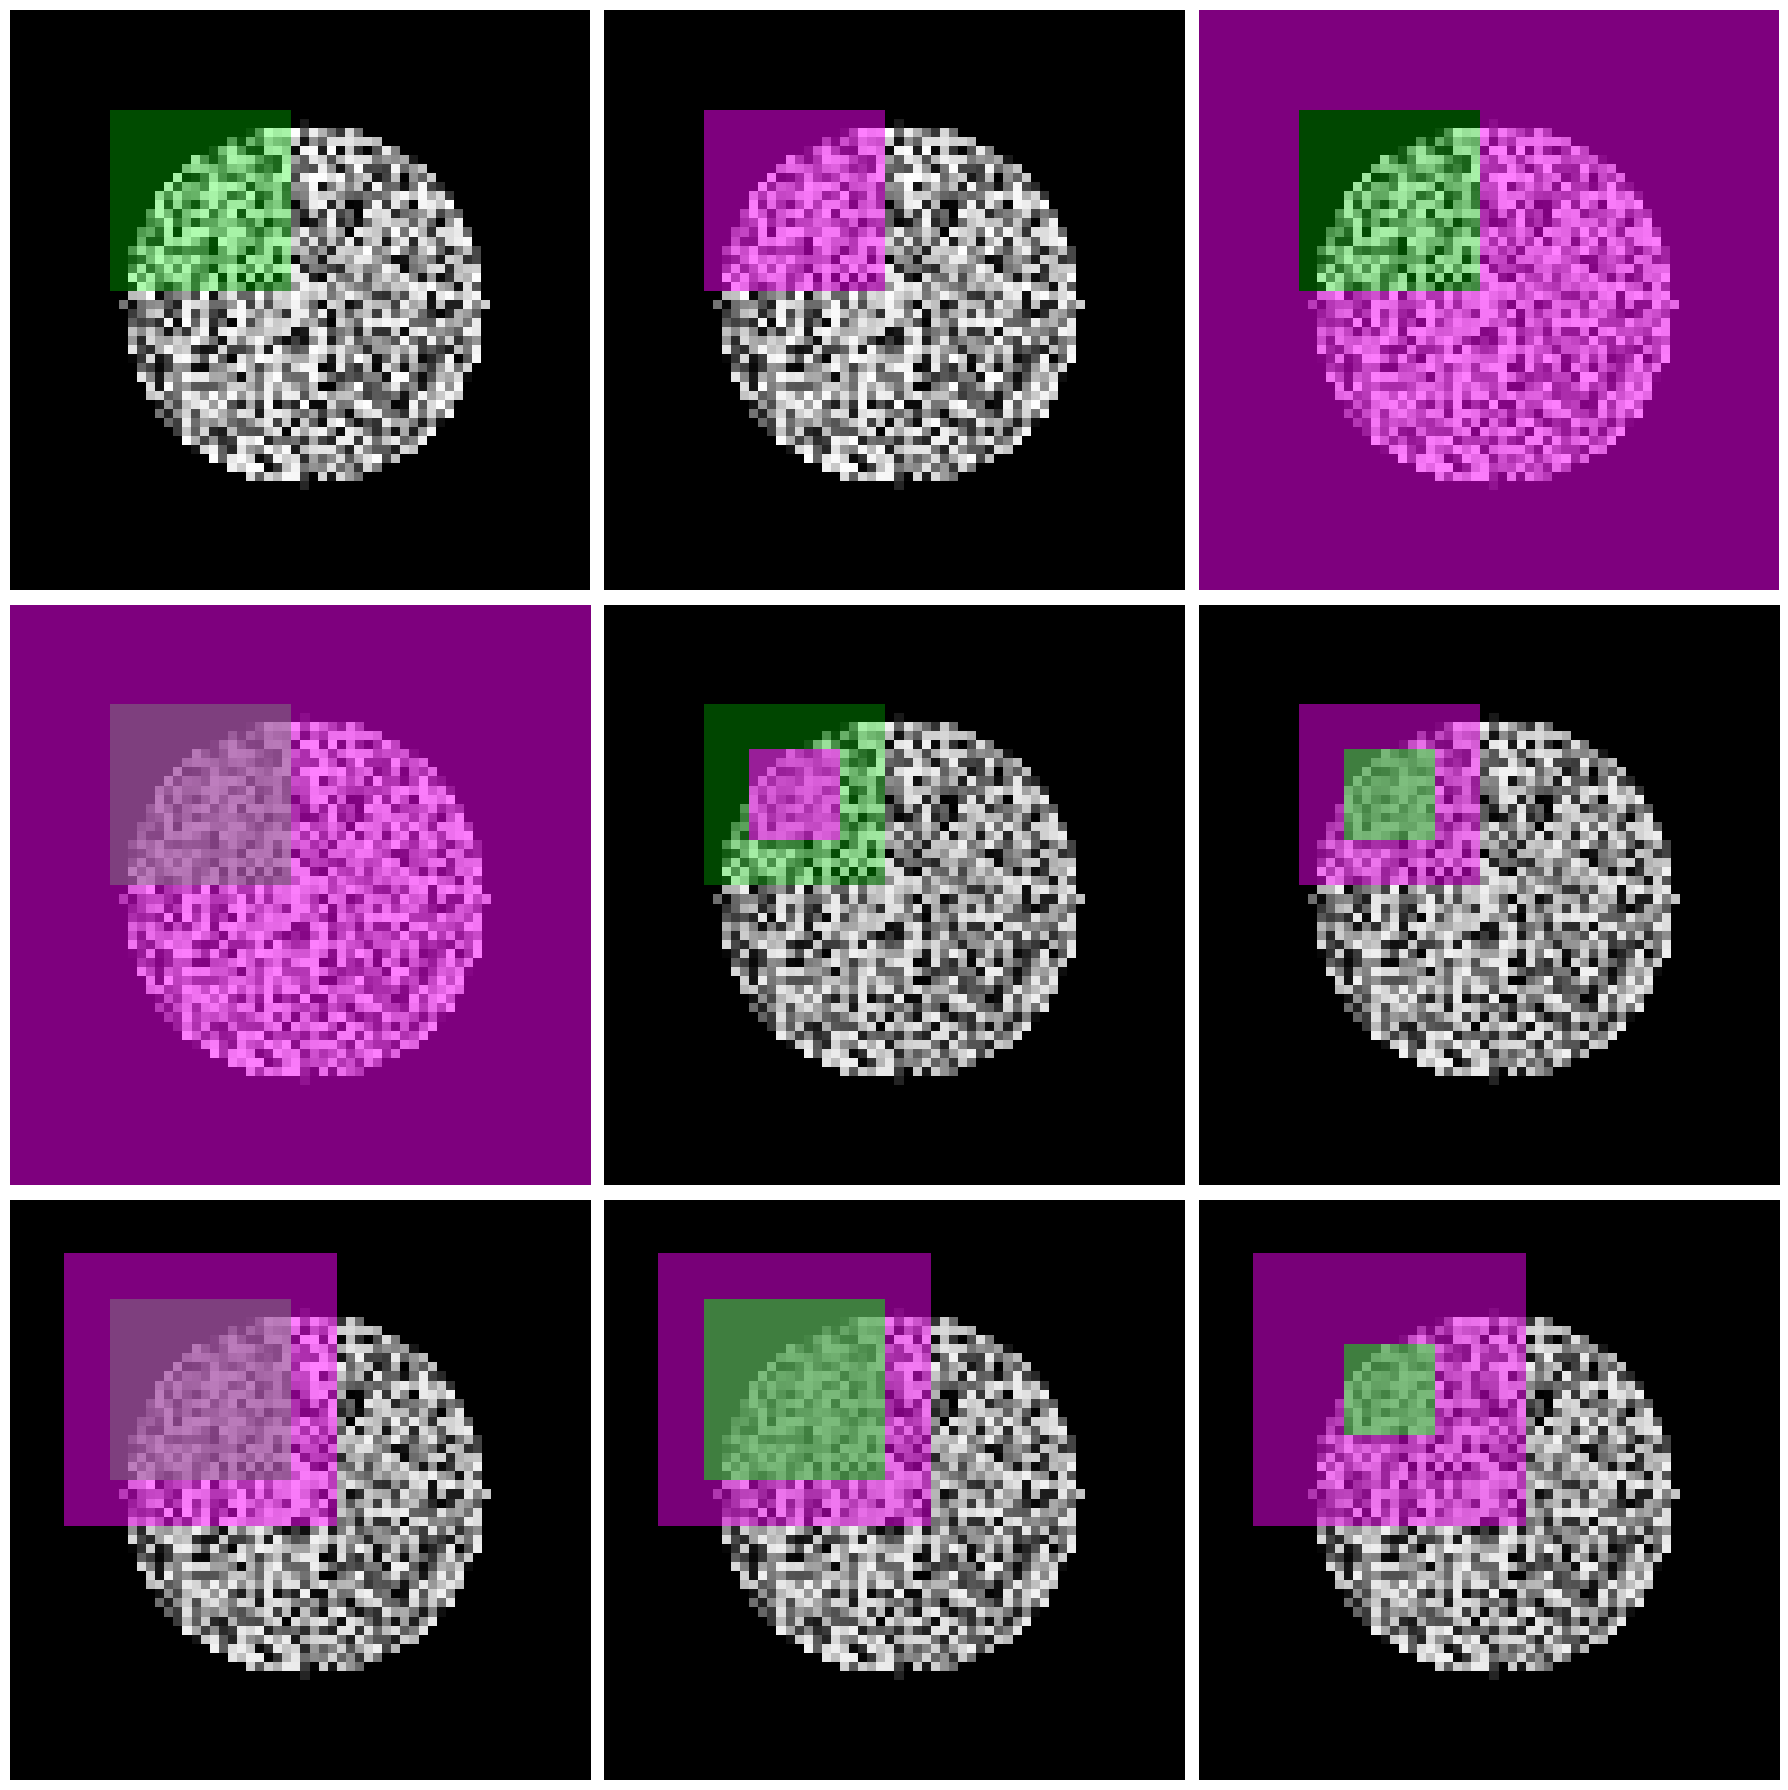

In [ ]:
region_fig, region_ax = plt.subplots(3,3, figsize=(18,18), layout='tight')

region_ax_flat = region_ax.ravel()

select_image = sphere_image
slice = 32 
# a. Original
displayCTSegOverlay(select_image, square_mask, slice, ax=region_ax_flat[0])

# b. ROI
displayCTSegOverlay(select_image, square_mask, slice, cmapSeg='cool', ax=region_ax_flat[1], alpha=0.5)

# c. Non-ROI
cool_cmap = mpl.colormaps['cool']
# make list of colours that is transparent for 0 and magenta for 1
binary_magenta = mcolors.ListedColormap([(0,0,0,0.1), cool_cmap(500)])

displayCTSegOverlay(select_image, square_mask, slice, ax=region_ax_flat[2])
region_ax_flat[2].imshow(sitk.GetArrayFromImage(non_roi_mask)[slice,:,:], cmap=binary_magenta, alpha=0.5)

# d. Full
binary_magenta_r = mcolors.ListedColormap([cool_cmap(500),(0,0,0,0.1)])
displayCTSegOverlay(select_image, square_mask, slice, ax=region_ax_flat[3], alpha=0.5)
region_ax_flat[3].imshow(sitk.GetArrayFromImage(full_mask)[slice,:,:], cmap=binary_magenta_r, alpha=0.5)

# e. Core
core_mask = create_square_mask(select_image, side_length=10)
displayCTSegOverlay(select_image, square_mask, slice, ax=region_ax_flat[4])
region_ax_flat[4].imshow(sitk.GetArrayFromImage(core_mask)[slice,:,:], cmap=binary_magenta, alpha=0.6)

# f. Inner ring
binary_green = mcolors.ListedColormap([(0,0,0,0.1), mpl.colormaps['brg'](500)])
displayCTSegOverlay(select_image, square_mask, slice, ax=region_ax_flat[5], cmapSeg=binary_magenta, alpha=0.5)
region_ax_flat[5].imshow(sitk.GetArrayFromImage(core_mask)[slice,:,:], cmap=binary_green, alpha=0.5)

# g. Expansion
expansion_mask = create_square_mask(select_image, side_length=30)
displayCTSegOverlay(select_image, square_mask, slice, ax=region_ax_flat[6], alpha=0.5)
region_ax_flat[6].imshow(sitk.GetArrayFromImage(expansion_mask)[slice,:,:], cmap=binary_magenta, alpha=0.5)

# h. Outer ring
displayCTSegOverlay(select_image, expansion_mask, slice, ax=region_ax_flat[7], cmapSeg=binary_magenta, alpha=0.5)
region_ax_flat[7].imshow(sitk.GetArrayFromImage(square_mask)[slice,:,:], cmap=binary_green, alpha=0.5)

# i. Inner and outer ring

displayCTSegOverlay(select_image, expansion_mask, slice, ax=region_ax_flat[8], cmapSeg=binary_magenta, alpha=0.5)
region_ax_flat[8].imshow(sitk.GetArrayFromImage(core_mask)[slice,:,:], cmap=binary_green, alpha=0.5)

## Cropping

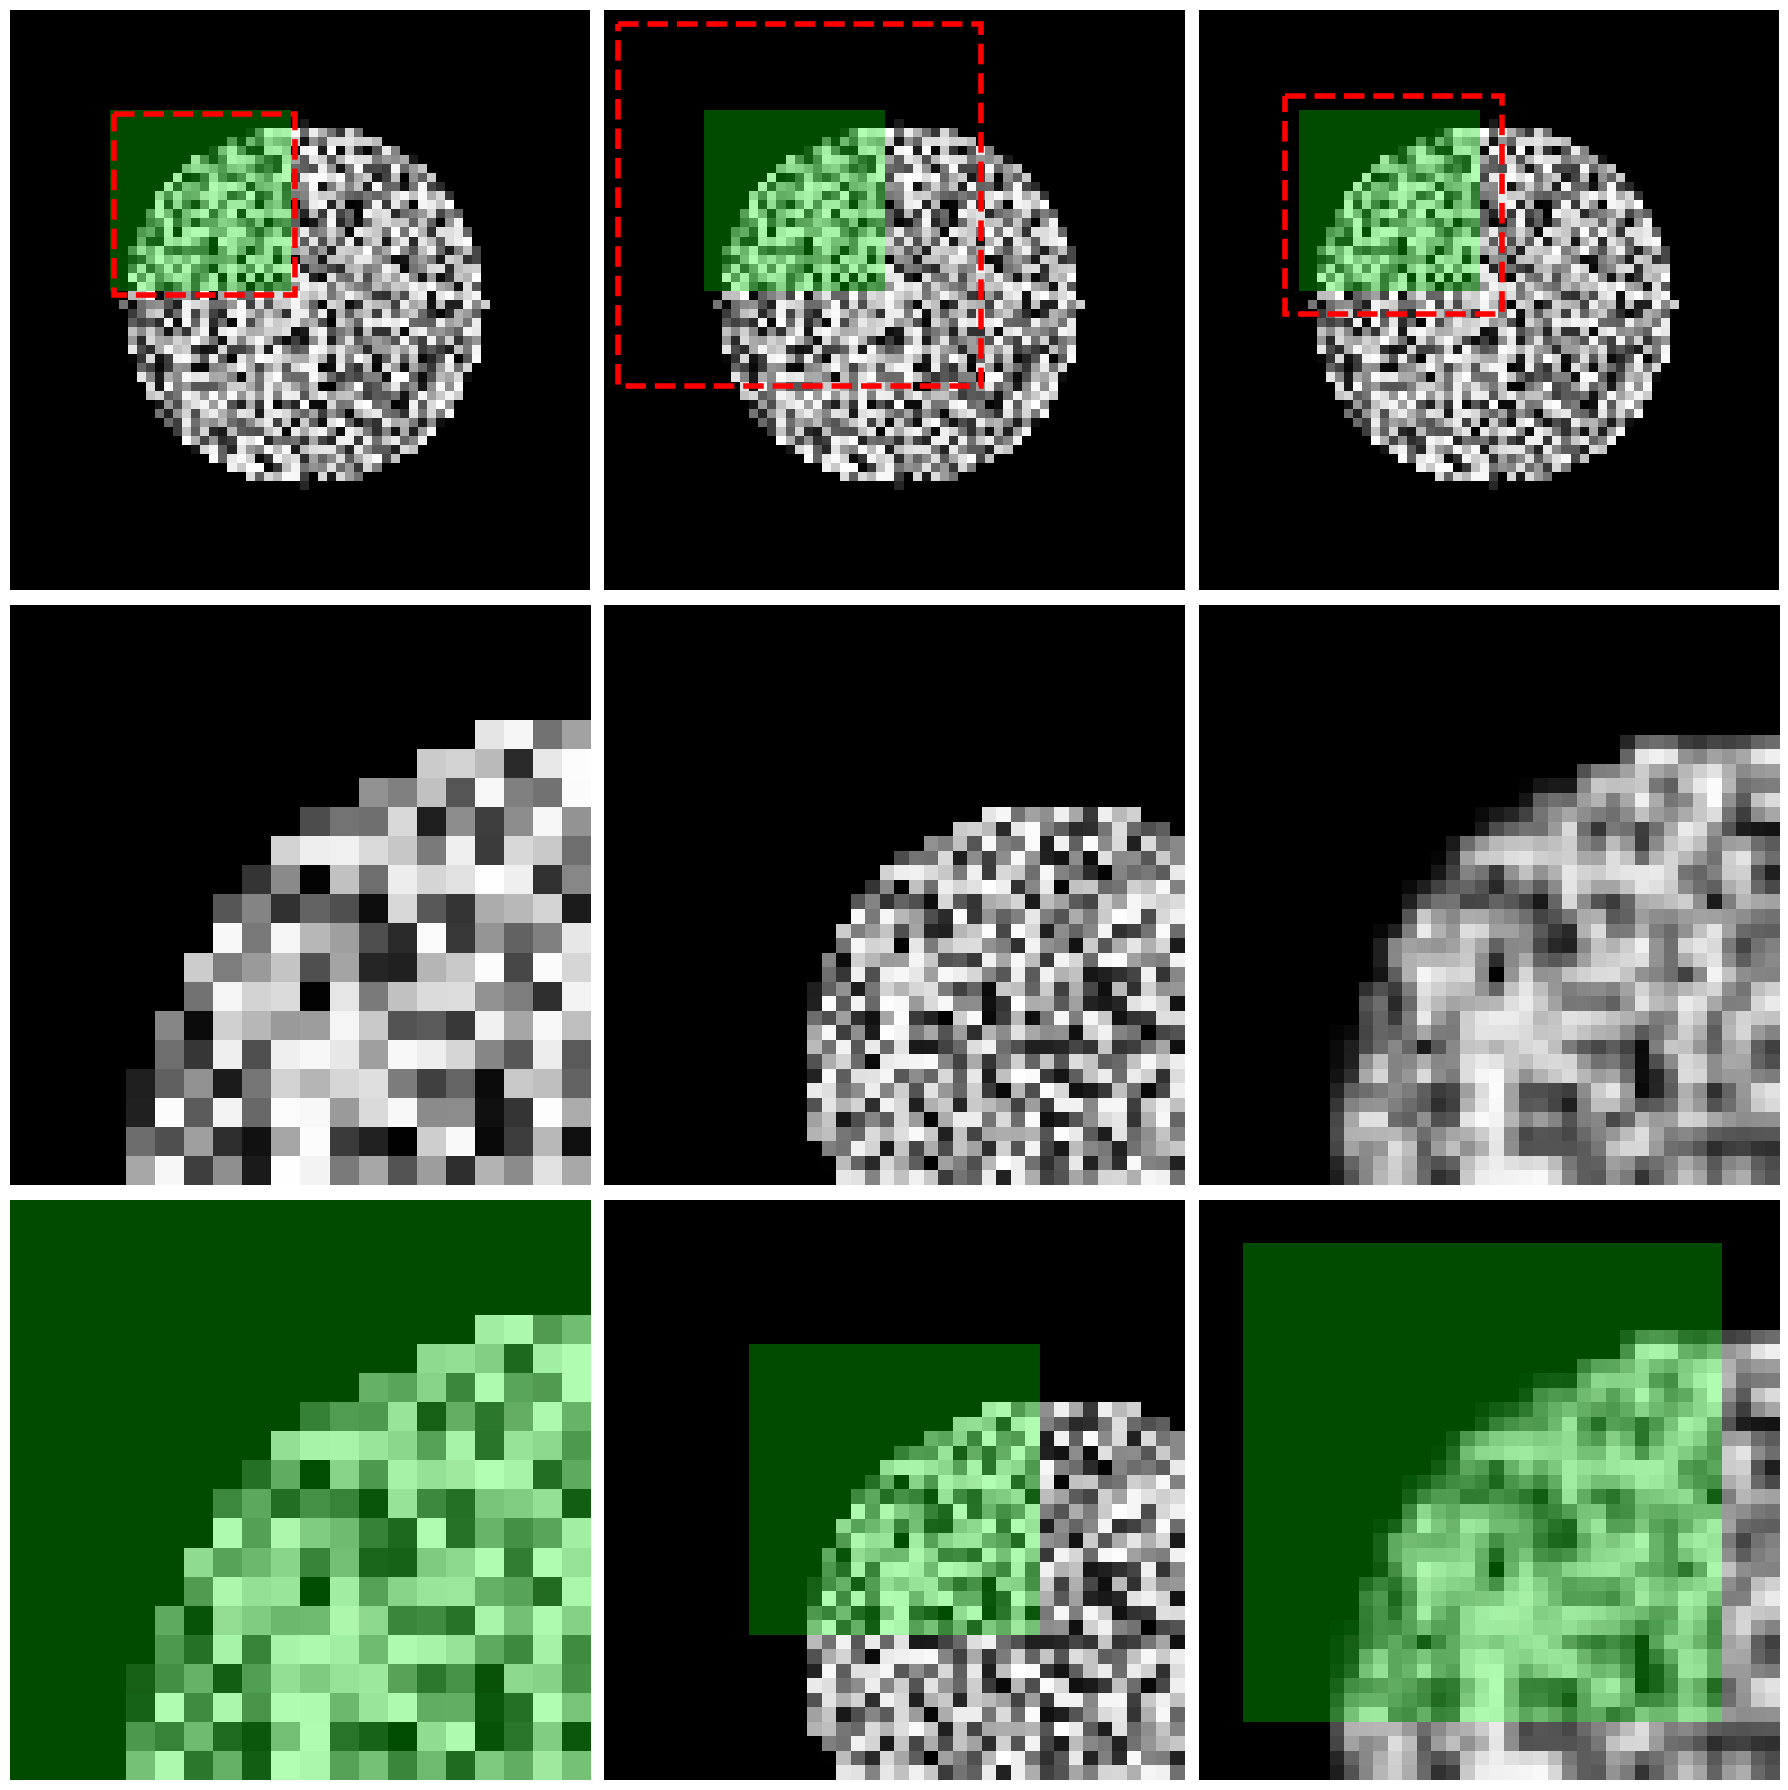

In [6]:
# resize = [50,50,50]
select_image = sphere_image
resize = None
slice = 32
crop_fig, crop_ax = plt.subplots(3,3, figsize=(18,18), layout='tight')

brg_cmap = mpl.colormaps['brg']
brg_green = brg_cmap(500)

for idx, crop in enumerate(['bounding_box', 'centroid', 'cube']):
    if crop == 'centroid':
        resize = 40

    crop_image, crop_mask = crop_and_resize_image_and_mask(select_image, 
                                                            square_mask, 
                                                            crop_method = crop, 
                                                            resize_dimension = resize)
    
    crop_slice_idx = crop_image.GetSize()[2] // 2

    crop_box = get_crop_box(crop, square_mask, resize)
    full_with_box_ax = crop_ax[0][idx]
    displayCTSegOverlay(select_image, square_mask, slice, ax=full_with_box_ax)
    rect = patches.Rectangle((crop_box.min.x, crop_box.min.y), crop_box.size.width, crop_box.size.height,
                        linewidth=4, edgecolor='r', facecolor='none', ls='--')
    full_with_box_ax.add_patch(rect)

    displayImageSlice(crop_image, crop_slice_idx, ax=crop_ax[1][idx])
    displayCTSegOverlay(crop_image, crop_mask, crop_slice_idx, ax=crop_ax[2][idx], cmapSeg=mcolors.ListedColormap([brg_green]))
    

## Negative Controls

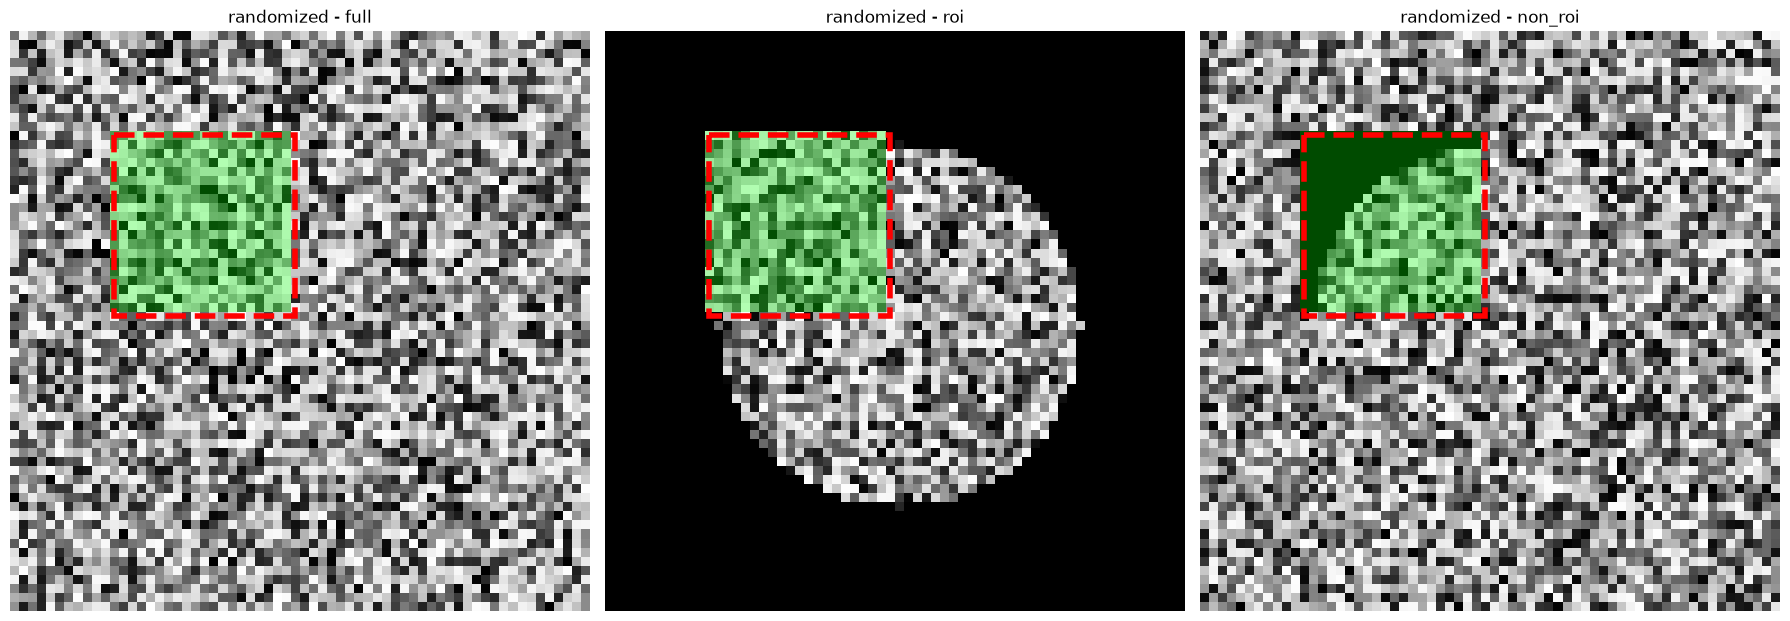

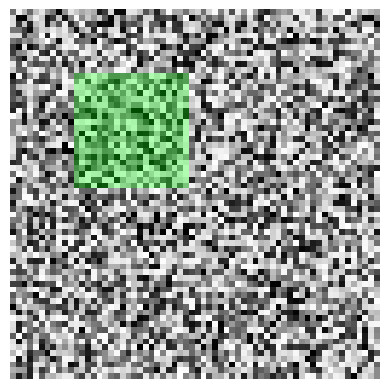

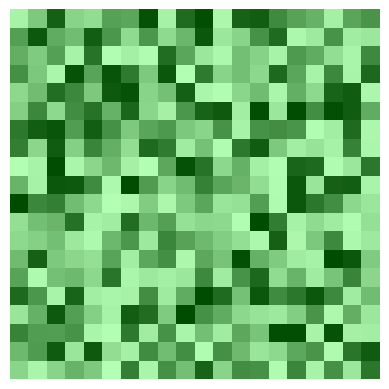

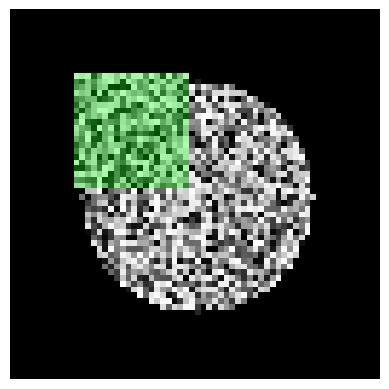

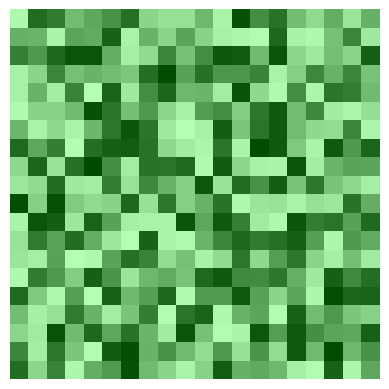

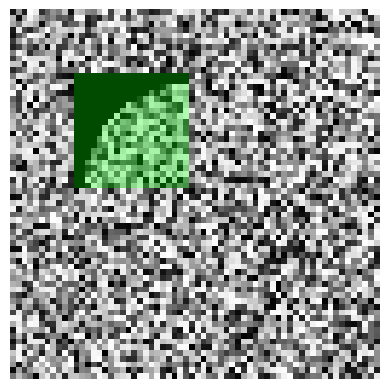

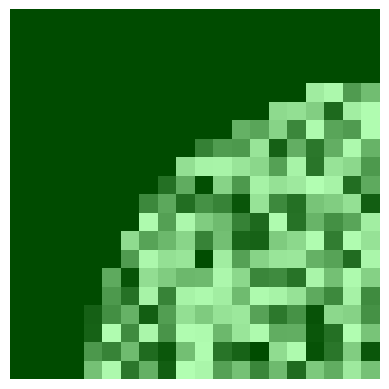

In [27]:
select_image = sphere_image
permutations = ['randomized']# 'randomized', , 'shuffled']
regions = ['full', 'roi', 'non_roi']
seed = 10

brg_cmap = mpl.colormaps['brg']
brg_green = brg_cmap(500)

manager = NegativeControlManager.from_strings(
        negative_control_types=permutations,
        region_types=regions,
        random_seed=seed
    )

slice = 32
nc_fig, nc_ax = plt.subplots(1,3, figsize=(18,18), layout='tight') 
nc_ax_flat = nc_ax.ravel()

crop = 'bounding_box'
resize = None
# Process and plot negative control images
for idx, proc_data in enumerate(manager.apply(select_image, square_mask)):
    proc_image, permutation, region = proc_data
    displayCTSegOverlay(proc_image, square_mask, slice) #, ax=nc_ax_flat[idx])
    nc_ax_flat[idx].set_title(f"{permutation} - {region}")

    
    crop_image, crop_mask = crop_and_resize_image_and_mask(proc_image, 
                                                            square_mask, 
                                                            crop_method = crop, 
                                                            resize_dimension = resize)

    crop_slice_idx = crop_image.GetSize()[2] // 2

    crop_box = get_crop_box(crop, square_mask, resize)
    full_with_box_ax = nc_ax_flat[idx] #+3]
    displayCTSegOverlay(proc_image, square_mask, slice, ax=full_with_box_ax)
    rect = patches.Rectangle((crop_box.min.x, crop_box.min.y), crop_box.size.width, crop_box.size.height,
                    linewidth=4, edgecolor='r', facecolor='none', ls='--')
    full_with_box_ax.add_patch(rect)

    displayCTSegOverlay(crop_image, crop_mask, crop_slice_idx, cmapSeg=mcolors.ListedColormap([brg_green]))#, ax=nc_ax_flat[idx+6])